# Page Rank

In [ ]:
import pandas as pd

# Load the data, skipping the first 4 metadata rows and using tab as delimiter
df = pd.read_csv('web-Google_10k.txt', sep='\t', skiprows=4, header=None, names=['FromNodeId', 'ToNodeId'])

# Display the first few rows to verify the data loading
display(df.head())

# Save the selected columns to a new CSV file
df[['FromNodeId', 'ToNodeId']].to_csv('graph_data.csv', index=False)

print("Data dari 'FromNodeId' dan 'ToNodeId' telah disimpan ke 'graph_data.csv'")

,FromNodeId,ToNodeId
0,0,11342
1,0,824020
2,0,867923
3,0,891835
4,11342,0


Data dari 'FromNodeId' dan 'ToNodeId' telah disimpan ke 'graph_data.csv'


In [ ]:
!pip install networkx matplotlib

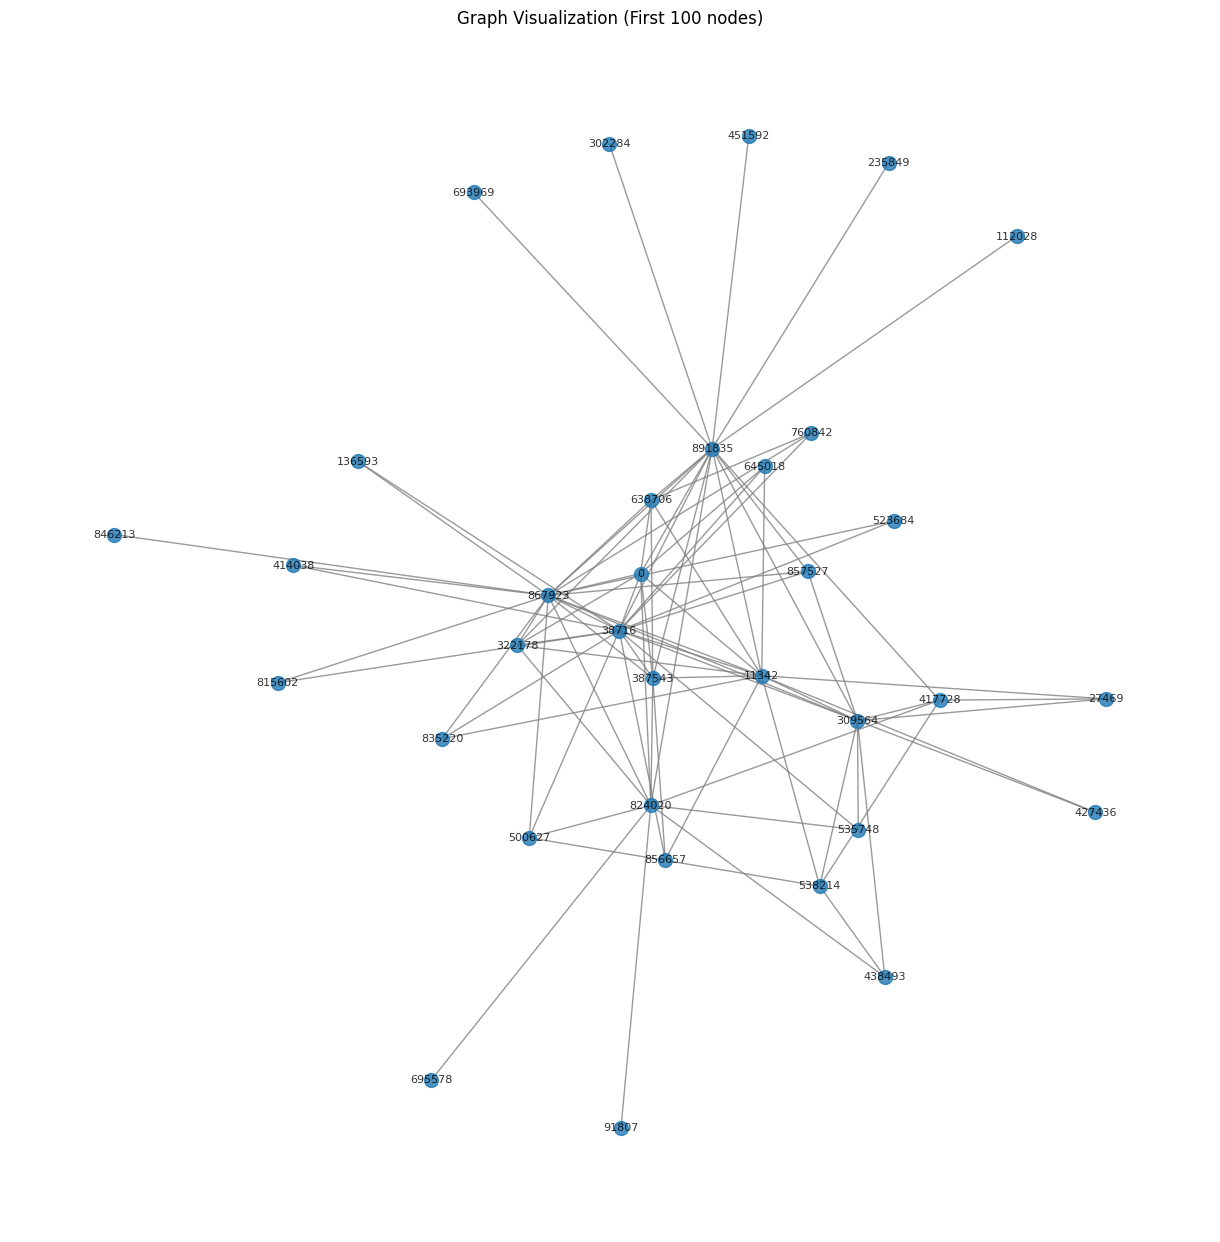

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Load the graph data from the CSV file
df_graph = pd.read_csv('graph_data.csv')

# Select the top 50 rows to get a smaller subset for visualization
df_subset = df_graph.head(100)

# Create a graph object from the subset
G_subset = nx.from_pandas_edgelist(df_subset, 'FromNodeId', 'ToNodeId')

# Draw the graph
plt.figure(figsize=(12, 12)) # Increased figure size for better visibility
nx.draw(G_subset, with_labels=True, node_size=100, font_size=8, alpha=0.8, edge_color='gray') # Adjusted node size and font size
plt.title("Graph Visualization (First 100 nodes)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import time

def pagerank(adj_matrix, d=0.85, max_iter=100, tol=1e-6):
    """
    Hitung PageRank dari matriks adjacency.

    Parameters:
        adj_matrix : array-like, shape (n, n)
            Matriks adjacency (1 jika ada link i -> j)
        d : float
            Damping factor (default: 0.85)
        max_iter : int
            Maksimum iterasi
        tol : float
            Toleransi konvergensi

    Returns:
        r : ndarray, shape (n,)
            Vektor PageRank
    """
    adj = np.array(adj_matrix, dtype=float)
    n = adj.shape[0]

    # Tangani dangling nodes (baris dengan jumlah 0)
    out_degree = np.sum(adj, axis=1)
    for i in range(n):
        if out_degree[i] == 0:
            adj[i, :] = 1.0

    # Normalisasi baris → jadi matriks transisi (baris jumlah = 1)
    # TAPI: PageRank asli menggunakan TRANSPOSE → aliran masuk
    # Jadi kita transpos untuk membuat kolom = out-link
    M = adj / np.sum(adj, axis=1, keepdims=True)
    M = M.T

    # Inisialisasi
    r = np.ones(n) / n
    teleport = (1 - d) / n

    for i in range(max_iter):
        r_new = d * M @ r + teleport
        diff = np.linalg.norm(r_new - r, 1)
        # Optional: Print progress
        # print(f"Iteration {i+1}, Diff: {diff:.6f}")
        if diff < tol:
            # print(f"Convergence reached at iteration {i+1}")
            break
        r = r_new
    # Optional: Print if max iterations reached without convergence
    # if i == max_iter - 1:
    #     print("Warning: Max iterations reached without convergence.")

    return r

df_graph = pd.read_csv('graph_data.csv')

df_subset = df_graph.head(100)

G_subset = nx.from_pandas_edgelist(df_subset, 'FromNodeId', 'ToNodeId', create_using=nx.DiGraph())

nodes_subset = list(G_subset.nodes())
n_subset = len(nodes_subset)
adj_matrix_subset = nx.adjacency_matrix(G_subset, nodelist=nodes_subset).todense()

start_time = time.time()

print(f"Calculating PageRank for {n_subset} nodes...")
pr_subset = pagerank(adj_matrix_subset)

end_time = time.time()
duration = end_time - start_time

pr_scores_subset = dict(zip(nodes_subset, pr_subset))

print(f"PageRank calculation completed in {duration:.2f} seconds")

print("\nPageRank for the 50 nodes:")
for node, score in pr_scores_subset.items():
    print(f"Node {node}: {score:.6f}")

Calculating PageRank for 34 nodes...
PageRank calculation completed in 0.00 seconds

PageRank for the 50 nodes:
Node 0: 0.065854
Node 11342: 0.056371
Node 824020: 0.031902
Node 867923: 0.058141
Node 891835: 0.057382
Node 27469: 0.022978
Node 38716: 0.026026
Node 309564: 0.021330
Node 322178: 0.025097
Node 387543: 0.025097
Node 427436: 0.022978
Node 538214: 0.022978
Node 638706: 0.024378
Node 645018: 0.022631
Node 835220: 0.026750
Node 856657: 0.025679
Node 91807: 0.020373
Node 417728: 0.052941
Node 438493: 0.028532
Node 500627: 0.032303
Node 535748: 0.023322
Node 695578: 0.020373
Node 136593: 0.023327
Node 414038: 0.023327
Node 523684: 0.023327
Node 760842: 0.027471
Node 815602: 0.023327
Node 846213: 0.022026
Node 857527: 0.029853
Node 112028: 0.022785
Node 235849: 0.022785
Node 302284: 0.022785
Node 451592: 0.022785
Node 693969: 0.022785


In [ ]:
# Keluarkan node node yang terhubung

print("Connections for each node in the 100-node graph subset:")
for node in G_subset.nodes():
    neighbors = list(G_subset.neighbors(node))
    if neighbors:
        print(f"Node {node} is connected to: {neighbors}")
    else:
        print(f"Node {node} has no outgoing connections in this subset.")

Connections for each node in the 100-node graph subset:
Node 0 is connected to: [11342, 824020, 867923, 891835, 38716, 322178, 387543, 638706, 645018]
Node 11342 is connected to: [0, 27469, 38716, 309564, 322178, 387543, 427436, 538214, 638706, 645018, 835220, 856657, 867923, 891835]
Node 824020 is connected to: [0, 91807, 322178, 387543, 417728, 438493, 500627, 535748, 695578, 867923, 891835]
Node 867923 is connected to: [0, 11342, 824020, 136593, 414038, 500627, 523684, 760842, 815602, 835220, 846213, 857527, 891835, 38716, 309564, 322178, 387543, 638706]
Node 891835 is connected to: [0, 11342, 824020, 867923, 112028, 235849, 302284, 417728, 451592, 693969, 857527, 38716, 309564, 322178, 387543, 638706]
Node 27469 is connected to: [11342, 417728, 309564]
Node 38716 is connected to: [11342, 0, 136593, 322178, 387543, 414038, 500627, 523684, 535748, 645018, 760842, 815602, 835220, 856657, 857527, 867923, 891835, 309564]
Node 309564 is connected to: [11342, 27469, 38716, 417728, 427436,